In [1]:
import json

import colorcet
import h5py
import matplotlib.pyplot as plt
import numba
import numpy as np

from lib.plots import set_axis
from lib.stats import fit_power_law

In [16]:
config_id = 20
filename = f"_outputs/output-{config_id}.h5"

with h5py.File(filename, "r") as store:
    phase_store = store["production"]
    config = json.loads(phase_store["metadata/config_source"][()])
    config_used = json.loads(phase_store["metadata/config"][()])

    positions_history = []
    for step_key in phase_store[".steps"]:
        positions = phase_store[step_key]["positions"][:]
        positions_history.append(positions)
    positions_history = np.array(positions_history)

In [17]:
for key, value in config["@meta"]["sweep_data"].items():
    print(f"{key:18s} {value}")

config_id          20
acetylation_level  0.2975
unloading_rate     0.2254312099735182
loading_constant   0.029545426659769534


In [18]:
def collect_msd(path: np.ndarray, lag: int) -> np.ndarray:
    squared_dists = np.zeros((lag,) + path.shape[1:-1])
    for t in range(0, len(path) - lag):
        squared_dists += ((path[t:t + lag] - path[t]) ** 2).sum(-1)
    return squared_dists / (len(path) - lag)

In [19]:
msd = collect_msd(positions_history, lag=100).mean(1)

frame_interval = config["sampling"]["timestep"] * config["sampling"]["sampling_interval"]
x = frame_interval * np.arange(len(msd))
y = msd
alpha, beta = fit_power_law(x, y)

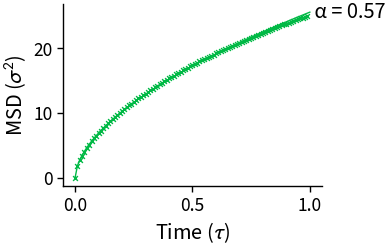

In [20]:
color = "C:g"

fig, ax = plt.subplots(figsize=(2.0, 1.3))

x = np.arange(len(msd)) * frame_interval
y = msd
ax.scatter(x, y, s=3, marker="x", color=color)

x = np.linspace(0, 1, num=100)
y = x**alpha * beta
ax.plot(x, y, color=color)

x = 1
y = beta
s = " α = %.2f" % alpha
ax.text(x, y, s, ha="left", va="center")

ax.set_xlabel(r"Time ($ \tau $)")
ax.set_ylabel(r"MSD ($ \sigma^2 $)")

set_axis(ax, "left bottom")

pass